# Drug Response EDA
## Predicting Cancer Cell Line Sensitivity to Drugs from Gene Expression

**Objective:** Build intuition for the three raw datasets before modeling. Specifically:
1. Understand each dataset's structure, quality, and coverage
2. Identify how the three sources link together via shared IDs
3. Select a **Target Drug** — one with high coverage (~945 cell lines) and high LN_IC50 variance, making it the best candidate for the initial deep learning model

**Datasets:**
| File | Source | Role |
|---|---|---|
| `OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv` | DepMap | Features: log(TPM+1) gene expression per cell line (~19k genes) |
| `GDSC2_fitted_dose_response_27Oct23.csv` | GDSC2 | Targets: LN_IC50 per drug × cell line |
| `Model.csv` | DepMap | Metadata bridge: maps `ModelID` (DepMap) ↔ `COSMIC_ID` (GDSC2) |

---
## Section 0 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Pandas display options ───────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = '../data/'
GDSC_PATH   = DATA_DIR + 'GDSC2_fitted_dose_response_27Oct23.csv'
MODEL_PATH  = DATA_DIR + 'Model.csv'
EXPR_PATH   = DATA_DIR + 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv'

print('Setup complete.')

# ── Output directory (all plots saved here) ────────────────────────────────
import os
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Plots will be saved to: {os.path.abspath(OUTPUT_DIR)}")

Setup complete.
Plots will be saved to: /app/output


---
## Section 1 — Load Raw Data

We load all three files and inspect their shape, dtypes, and first rows. The expression file is wide (~19k columns), so loading is the most memory-intensive step.

In [2]:
# ── 1a. GDSC2 Dose-Response ──────────────────────────────────────────────────
# Contains one row per (cell line, drug) experiment.
# Key columns: COSMIC_ID (cell line ID), DRUG_NAME, LN_IC50
gdsc = pd.read_csv(GDSC_PATH)

print(f'GDSC2 shape: {gdsc.shape}')
print(f'Columns: {list(gdsc.columns)}')
gdsc.head(3)

GDSC2 shape: (242036, 19)
Columns: ['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1000,-1.4639,0.9302,0.0891,0.4331
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1000,-4.8695,0.6150,0.1114,-1.4211
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1000,-3.3606,0.7911,0.1429,-0.5996


In [3]:
# ── 1b. Model Metadata ───────────────────────────────────────────────────────
# DepMap model metadata. The critical columns are:
#   ModelID  — DepMap's identifier for each cell line model
#   COSMICID — Sanger/GDSC identifier, links to GDSC2 COSMIC_ID
model = pd.read_csv(MODEL_PATH, low_memory=False)

print(f'Model shape: {model.shape}')
print(f'Columns: {list(model.columns[:15])} ... ({model.shape[1]} total)')
model[['ModelID', 'CellLineName', 'COSMICID', 'OncotreeLineage']].head(3)

Model shape: (2132, 49)
Columns: ['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures', 'RRID', 'Age', 'AgeCategory', 'Sex', 'PatientRace'] ... (49 total)


,ModelID,CellLineName,COSMICID,OncotreeLineage
0,ACH-000001,NIH:OVCAR-3,905933.0000,Ovary/Fallopian Tube
1,ACH-000002,HL-60,905938.0000,Myeloid
2,ACH-000003,CACO2,NaN,Bowel


In [4]:
# ── 1c. Gene Expression (TPM log(x+1)) ──────────────────────────────────────
# Rows: cell line model conditions. Columns: genes in 'SYMBOL (ENTREZ_ID)' format.
# The CSV has an unnamed integer row-index as the first column (artifact of how it was saved).
# We drop it and use the existing 'ModelID' column directly.
expr_raw = pd.read_csv(EXPR_PATH)
if expr_raw.columns[0].startswith('Unnamed'):
    expr_raw = expr_raw.drop(columns=[expr_raw.columns[0]])

print(f'Expression shape: {expr_raw.shape}')
print(f'First 8 columns: {list(expr_raw.columns[:8])}')
expr_raw.iloc[:3, :6]

Expression shape: (1754, 19220)
First 8 columns: ['SequencingID', 'ModelID', 'IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC', 'TSPAN6 (7105)', 'TNMD (64102)', 'DPM1 (8813)']


,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105)
0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,4.9566
1,CDS-02TzJp,ACH-001289,Yes,MC-001289-BpdI,Yes,4.9550
2,CDS-0693hw,ACH-001339,Yes,MC-001339-5nRN,Yes,3.4220


---
## Section 2 — Data Quality Overview

Before merging, we audit each dataset independently for missing values, duplicate IDs, and range sanity.

In [5]:
# ── 2a. GDSC2 Quality ───────────────────────────────────────────────────────
print('=== GDSC2 Dose-Response ===')
print(f"  Total records:       {len(gdsc):,}")
print(f"  Unique drugs:        {gdsc['DRUG_NAME'].nunique():,}")
print(f"  Unique COSMIC_IDs:   {gdsc['COSMIC_ID'].nunique():,}")
print(f"  LN_IC50 nulls:       {gdsc['LN_IC50'].isna().sum():,}")
print(f"  LN_IC50 range:       [{gdsc['LN_IC50'].min():.2f}, {gdsc['LN_IC50'].max():.2f}]")
print()

# Null summary for key columns
key_cols = ['COSMIC_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'TCGA_DESC']
null_summary = gdsc[key_cols].isnull().sum().rename('Null Count')
null_summary.to_frame()

=== GDSC2 Dose-Response ===
  Total records:       242,036
  Unique drugs:        286
  Unique COSMIC_IDs:   969
  LN_IC50 nulls:       0
  LN_IC50 range:       [-8.75, 13.82]



,Null Count
COSMIC_ID,0
DRUG_NAME,0
LN_IC50,0
AUC,0
TCGA_DESC,1067


In [6]:
# ── 2b. Model.csv Quality ────────────────────────────────────────────────────
print('=== Model Metadata ===')
print(f"  Total models:        {len(model):,}")
print(f"  Unique ModelIDs:     {model['ModelID'].nunique():,}")
print(f"  COSMICID non-null:   {model['COSMICID'].notna().sum():,}")
print(f"  COSMICID null:       {model['COSMICID'].isna().sum():,}")
print()

# Normalise column name to match GDSC2 (COSMIC_ID vs COSMICID)
model_clean = model[['ModelID', 'CellLineName', 'COSMICID', 'OncotreeLineage']].copy()
model_clean = model_clean.rename(columns={'COSMICID': 'COSMIC_ID'})
model_clean = model_clean.dropna(subset=['COSMIC_ID'])
model_clean['COSMIC_ID'] = model_clean['COSMIC_ID'].astype(int)

print(f"  Models with a valid COSMIC_ID (usable for merge): {len(model_clean):,}")
model_clean.head(3)

=== Model Metadata ===
  Total models:        2,132
  Unique ModelIDs:     2,132
  COSMICID non-null:   977
  COSMICID null:       1,155

  Models with a valid COSMIC_ID (usable for merge): 977


,ModelID,CellLineName,COSMIC_ID,OncotreeLineage
0,ACH-000001,NIH:OVCAR-3,905933,Ovary/Fallopian Tube
1,ACH-000002,HL-60,905938,Myeloid
3,ACH-000004,HEL,907053,Myeloid


In [7]:
# ── 2c. Expression Quality ───────────────────────────────────────────────────
print('=== Gene Expression ===')
print(f"  Total rows:          {len(expr_raw):,}")
print(f"  Unique ModelIDs:     {expr_raw['ModelID'].nunique():,}")

# Some cell lines have multiple sequencing entries (different conditions / replicates).
# The 'IsDefaultEntryForModel' column (string 'Yes'/'No') marks the canonical entry.
# We keep only the default entry so each cell line contributes exactly one expression profile.
if 'IsDefaultEntryForModel' in expr_raw.columns:
    dup_models = expr_raw['ModelID'].duplicated().sum()
    print(f"  Duplicate ModelID rows: {dup_models:,}")
    print(f"  IsDefaultEntryForModel value counts:\n{expr_raw['IsDefaultEntryForModel'].value_counts().to_string()}")
    expr = expr_raw[expr_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    print(f"\n  After filtering to default entries: {len(expr):,} rows")
else:
    expr = expr_raw.copy()
    print('  IsDefaultEntryForModel column not found — using all rows.')

# Identify gene expression columns (everything that is not a metadata column)
meta_cols = ['ModelID', 'SequencingID', 'IsDefaultEntryForModel',
             'ModelConditionID', 'IsDefaultEntryForMC']
gene_cols = [c for c in expr.columns if c not in meta_cols]
print(f"  Gene columns: {len(gene_cols):,}")
print(f"  Example gene columns: {gene_cols[:5]}")

=== Gene Expression ===
  Total rows:          1,754
  Unique ModelIDs:     1,699
  Duplicate ModelID rows: 55
  IsDefaultEntryForModel value counts:
IsDefaultEntryForModel
Yes    1699
No       55



  After filtering to default entries: 1,699 rows
  Gene columns: 19,215
  Example gene columns: ['TSPAN6 (7105)', 'TNMD (64102)', 'DPM1 (8813)', 'SCYL3 (57147)', 'FIRRM (55732)']


---
## Section 3 — ID Mapping & Merge Coverage

The three datasets are linked through two ID types:
- **COSMIC_ID** — connects GDSC2 drug responses to Model.csv
- **ModelID** — connects Model.csv to the expression matrix

We track how many cell lines survive each merge step.

In [8]:
# ── Step 1: GDSC2 × Model (COSMIC_ID join) ──────────────────────────────────
gdsc_model = gdsc.merge(model_clean, on='COSMIC_ID', how='inner')

n_cl_gdsc      = gdsc['COSMIC_ID'].nunique()
n_cl_model     = model_clean['COSMIC_ID'].nunique()
n_cl_after_s1  = gdsc_model['COSMIC_ID'].nunique()

print(f'Unique cell lines in GDSC2:              {n_cl_gdsc:,}')
print(f'Unique cell lines in Model (w/ COSMIC):  {n_cl_model:,}')
print(f'After GDSC2 × Model inner join:          {n_cl_after_s1:,}')

Unique cell lines in GDSC2:              969
Unique cell lines in Model (w/ COSMIC):  977
After GDSC2 × Model inner join:          946


In [9]:
# ── Step 2: (GDSC × Model) × Expression (ModelID join) ──────────────────────
expr_ids = set(expr['ModelID'].unique())
gdsc_model_expr = gdsc_model[gdsc_model['ModelID'].isin(expr_ids)].copy()

n_cl_after_s2 = gdsc_model_expr['COSMIC_ID'].nunique()
print(f'Unique cell lines in Expression:         {len(expr_ids):,}')
print(f'After adding Expression filter:          {n_cl_after_s2:,}')

Unique cell lines in Expression:         1,699
After adding Expression filter:          698


In [10]:
# ── Deduplication: one LN_IC50 per (cell line, drug) ────────────────────────
# GDSC2 can contain multiple NLME curve fits for the same (COSMIC_ID, DRUG_NAME) pair
# (different experimental runs or fitting attempts). We must deduplicate before computing
# per-drug statistics, otherwise coverage counts and variance estimates will be inflated.
# NOTE: group only by the true composite key (COSMIC_ID, DRUG_NAME, ModelID).
# Including metadata columns like TCGA_DESC in the groupby causes rows with NaN
# tissue labels to be silently dropped (pandas dropna=True default), losing data.

n_before = len(gdsc_model_expr)
gdsc_model_expr = (
    gdsc_model_expr
    .groupby(['COSMIC_ID', 'DRUG_NAME', 'ModelID'], as_index=False)
    .agg(
        CellLineName=('CellLineName', 'first'),
        OncotreeLineage=('OncotreeLineage', 'first'),
        TCGA_DESC=('TCGA_DESC', 'first'),
        LN_IC50=('LN_IC50', 'mean'),
        AUC=('AUC', 'mean')
    )
)
n_after = len(gdsc_model_expr)

print(f'Rows before dedup: {n_before:,}')
print(f'Rows after dedup:  {n_after:,}  ({n_before - n_after:,} duplicate curve fits removed)')
print(f'Unique cell lines: {gdsc_model_expr["COSMIC_ID"].nunique():,}')
print(f'Unique drugs:      {gdsc_model_expr["DRUG_NAME"].nunique():,}')

Rows before dedup: 177,029


Rows after dedup:  172,259  (4,770 duplicate curve fits removed)
Unique cell lines: 698
Unique drugs:      286


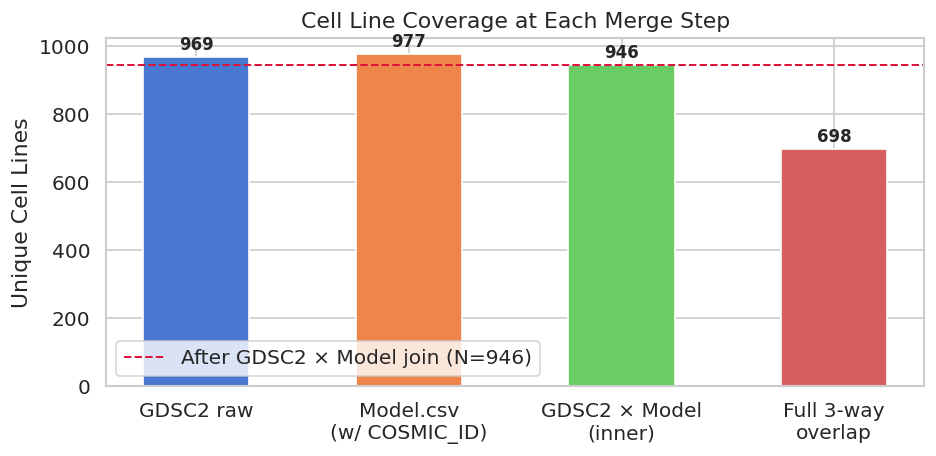


→ Final usable cell lines for modeling: 698


In [11]:
# ── Visualise merge funnel ───────────────────────────────────────────────────
stages = ['GDSC2 raw', 'Model.csv\n(w/ COSMIC_ID)', 'GDSC2 × Model\n(inner)', 'Full 3-way\noverlap']
counts = [n_cl_gdsc, n_cl_model, n_cl_after_s1, n_cl_after_s2]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stages, counts, color=sns.color_palette('muted', 4), edgecolor='white', width=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(n_cl_after_s1, color='crimson', linestyle='--', linewidth=1.2, label=f'After GDSC2 × Model join (N={n_cl_after_s1})')
ax.set_ylabel('Unique Cell Lines')
ax.set_title('Cell Line Coverage at Each Merge Step')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "merge_funnel.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f'\n→ Final usable cell lines for modeling: {n_cl_after_s2:,}')

---
## Section 4 — Coverage Check: Drugs × Cell Lines

For each drug in the fully-merged dataset, we count how many unique cell lines it was tested on. High coverage is essential — a drug tested on only a handful of lines gives too little data to train a DL model.

In [12]:
# Coverage = number of unique cell lines tested per drug (in the merged data)
coverage = (
    gdsc_model_expr
    .groupby('DRUG_NAME')['COSMIC_ID']
    .nunique()
    .rename('n_cell_lines')
    .sort_values(ascending=False)
    .reset_index()
)

print(f'Total drugs in merged dataset: {len(coverage):,}')
print(f'\nTop 10 by coverage:')
coverage.head(10)

Total drugs in merged dataset: 286

Top 10 by coverage:


,DRUG_NAME,n_cell_lines
0,MG-132,698
1,Palbociclib,697
2,Staurosporine,697
3,Docetaxel,697
4,5-Fluorouracil,697
5,Camptothecin,697
6,MK-2206,697
7,PD0325901,697
8,Nutlin-3a (-),697
9,Selumetinib,696


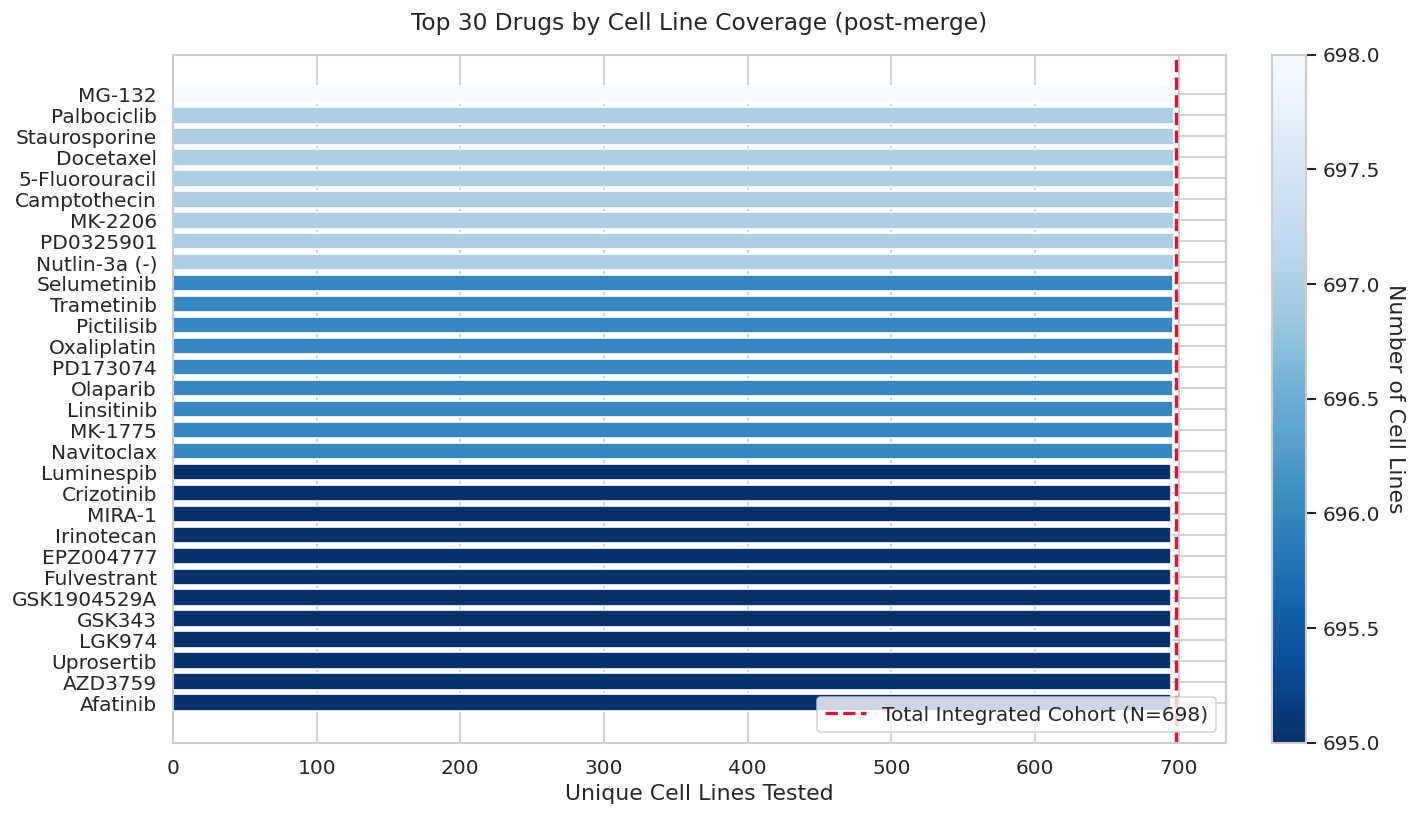

In [13]:
# ── Plot top 30 drugs by coverage ────────────────────────────────────────────
top30_cov = coverage.head(30)

fig, ax = plt.subplots(figsize=(12, 7))
# Create the bars
norm = plt.Normalize(top30_cov['n_cell_lines'].min(), top30_cov['n_cell_lines'].max())
sm = plt.cm.ScalarMappable(cmap="Blues_r", norm=norm)
colors = sm.to_rgba(top30_cov['n_cell_lines'][::-1])

bars = ax.barh(top30_cov['DRUG_NAME'][::-1], top30_cov['n_cell_lines'][::-1],
               color=colors, edgecolor='white')

# Add the red 'Target' line
ax.axvline(n_cl_after_s2, color='crimson', linestyle='--', linewidth=2,
           label=f'Total Integrated Cohort (N={n_cl_after_s2})')

# Add a Colorbar as a "Legend" for the blue intensity
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Number of Cell Lines', rotation=270, labelpad=15)

ax.set_xlabel('Unique Cell Lines Tested')
ax.set_title('Top 30 Drugs by Cell Line Coverage (post-merge)', fontsize=14, pad=15)

# Place the legend in a clear spot
ax.legend(loc='lower right', frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "drug_coverage_top30.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5 — Variance Analysis: LN_IC50 per Drug

High LN_IC50 variance means the drug kills some cell lines at much lower concentrations than others — indicating a real biological signal that a model can learn. We focus on high-coverage drugs (≥690 cell lines).

In [14]:
# Compute per-drug statistics on the deduplicated merged data.
# Use nunique on COSMIC_ID for coverage — not count(), which would be inflated
# if any duplicate (cell line, drug) pairs had survived the dedup step.
drug_stats = (
    gdsc_model_expr
    .groupby('DRUG_NAME')
    .agg(
        n_cell_lines=('COSMIC_ID', 'nunique'),
        mean=('LN_IC50', 'mean'),
        std=('LN_IC50', 'std'),
        variance=('LN_IC50', 'var'),
        iqr=('LN_IC50', lambda x: x.quantile(0.75) - x.quantile(0.25))
    )
    .reset_index()
    .sort_values('variance', ascending=False)
)

# Restrict to high-coverage drugs
drug_stats_hc = drug_stats[drug_stats['n_cell_lines'] >= 690].copy()

print(f'High-coverage drugs (≥690 cell lines): {len(drug_stats_hc)}')
drug_stats_hc.head(10)

High-coverage drugs (≥690 cell lines): 78


,DRUG_NAME,n_cell_lines,mean,std,variance,iqr
125,Gemcitabine,694,-0.6294,3.0344,9.2074,4.9010
84,Dasatinib,692,1.3376,2.3366,5.4597,2.9794
254,Trametinib,696,0.1483,2.2332,4.9870,2.8067
87,Docetaxel,697,-3.5056,2.1535,4.6375,3.3871
195,PD0325901,697,1.2570,2.1043,4.4280,2.6735
179,Navitoclax,696,1.7879,1.9591,3.8380,2.4119
137,Irinotecan,695,2.6036,1.9087,3.6431,2.7164
269,Venetoclax,690,2.0541,1.8937,3.5860,1.4954
73,Camptothecin,697,-2.1784,1.8573,3.4497,2.5030
158,Luminespib,695,-2.0350,1.8569,3.4480,2.3723


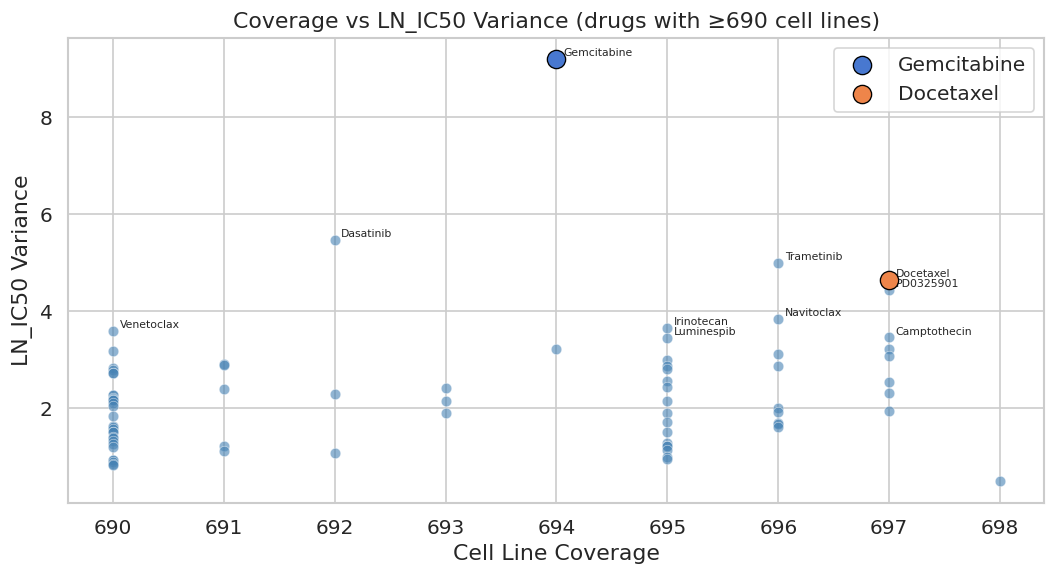

In [15]:
# ── Coverage vs Variance scatter ─────────────────────────────────────────────
# NOTE: do NOT reassign drug_stats_hc here — we need the full high-coverage
# dataframe in Section 6. Use a local variable for plotting only.
plot_df = drug_stats_hc.copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(plot_df['n_cell_lines'], plot_df['variance'],
           alpha=0.6, s=40, color='steelblue', edgecolors='white', linewidths=0.4)

# Annotate the top 10 by variance
for _, row in plot_df.head(10).iterrows():
    ax.annotate(row['DRUG_NAME'], (row['n_cell_lines'], row['variance']),
                fontsize=6.5, xytext=(4, 2), textcoords='offset points')

# Highlight our two main candidates
candidates = ['Gemcitabine', 'Docetaxel']
for drug in candidates:
    row = plot_df[plot_df['DRUG_NAME'] == drug]
    if not row.empty:
        ax.scatter(row['n_cell_lines'], row['variance'], s=120, zorder=5,
                   label=drug, edgecolors='black', linewidths=0.8)

ax.set_xlabel('Cell Line Coverage')
ax.set_ylabel('LN_IC50 Variance')
ax.set_title('Coverage vs LN_IC50 Variance (drugs with ≥690 cell lines)')
if ax.get_legend_handles_labels()[1]:
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "coverage_vs_variance.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Section 6 — Target Drug Selection

We now combine coverage and variance to choose our **Target Drug** for the first deep learning model.

**Selection criteria:**
1. **Coverage ≥ 690** cell lines (enough data to train/validate/test)
2. **Highest LN_IC50 variance** among qualifying drugs (strong biological signal)
3. Known clinical relevance and mechanistic interpretability are a bonus

**Key candidates:**
- **Gemcitabine** — top variance, widely used in solid tumours, sensitivity strongly linked to a handful of known genes (DCK, SLC29A1), making it highly interpretable
- **Docetaxel** — second highest variance, taxane with broad clinical use

In [16]:
# ── Stats for Docetaxel and Selumetinib specifically ─────────────────────────
for drug in ['Docetaxel', 'Gemcitabine']:
    row = drug_stats_hc[drug_stats_hc['DRUG_NAME'] == drug]
    if not row.empty:
        r = row.iloc[0]
        print(f"{drug}: coverage={r['n_cell_lines']}, variance={r['variance']:.4f}, std={r['std']:.4f}")
    else:
        print(f"{drug}: NOT FOUND in high-coverage drugs")

Docetaxel: coverage=697, variance=4.6375, std=2.1535
Gemcitabine: coverage=694, variance=9.2074, std=3.0344


In [17]:
# ── Select Target Drug ───────────────────────────────────────────────────────
TARGET_DRUG = drug_stats_hc.iloc[0]['DRUG_NAME']  # Top drug by variance among high-coverage
target_stats = drug_stats_hc[drug_stats_hc['DRUG_NAME'] == TARGET_DRUG].iloc[0]

print(f'>>> Selected Target Drug: {TARGET_DRUG}')
print(f'    Coverage:  {target_stats["n_cell_lines"]:,} cell lines')
print(f'    Mean LN_IC50:  {target_stats["mean"]:.4f}')
print(f'    Std LN_IC50:   {target_stats["std"]:.4f}')
print(f'    Variance:      {target_stats["variance"]:.4f}')

>>> Selected Target Drug: Gemcitabine
    Coverage:  694 cell lines
    Mean LN_IC50:  -0.6294
    Std LN_IC50:   3.0344
    Variance:      9.2074


##### **Justification:** The selected drug has the highest LN_IC50 variance among all drugs with sufficient cell line coverage (≥690). High variance is critical for supervised learning — it means the model has a meaningful signal to predict, rather than near-constant values. Wide coverage ensures enough training samples to learn generalizable patterns from the ~19,000-dimensional gene expression feature space.

##### **Gemcitabine** sensitivity is notoriously linked to the expression of a few key genes like DCK (Deoxycytidine kinase) and SLC29A1. If our feature selection finds these, you know your pipeline is working perfectly.

---
## Section 7 — Target Drug Deep Dive

Now we zoom into the selected drug to understand the distribution of our prediction target and its relationship with tissue type.

In [18]:
# Subset merged data to the target drug
target_df = gdsc_model_expr[gdsc_model_expr['DRUG_NAME'] == TARGET_DRUG].copy()

print(f"Target drug: {TARGET_DRUG}")
print(f"Records: {len(target_df):,}")
print(f"Unique cell lines: {target_df['COSMIC_ID'].nunique():,}")
print()
print(target_df['LN_IC50'].describe())

Target drug: Gemcitabine
Records: 694
Unique cell lines: 694

count   694.0000
mean     -0.6294
std       3.0344
min      -6.3367
25%      -3.1444
50%      -1.0078
75%       1.7566
max       7.7169
Name: LN_IC50, dtype: float64


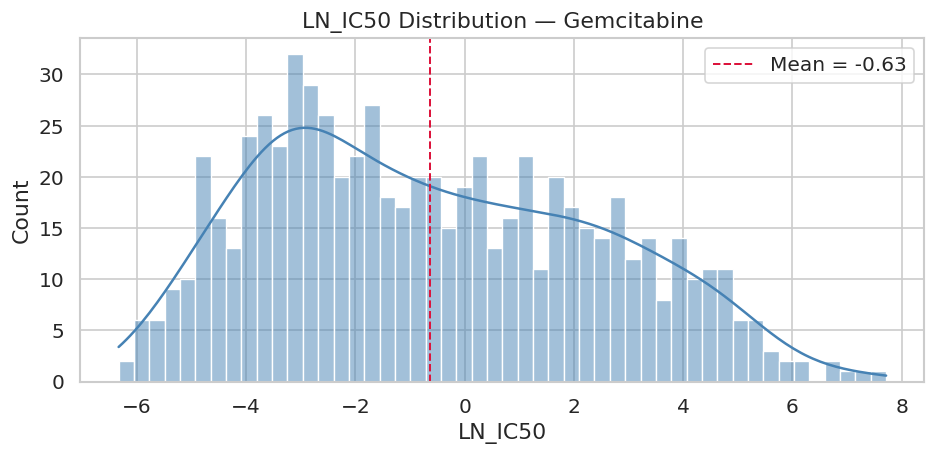

In [19]:
# ── LN_IC50 distribution ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(target_df['LN_IC50'], kde=True, bins=50, color='steelblue', ax=ax)
ax.axvline(target_df['LN_IC50'].mean(), color='crimson', linestyle='--',
           linewidth=1.2, label=f"Mean = {target_df['LN_IC50'].mean():.2f}")
ax.set_xlabel('LN_IC50')
ax.set_title(f'LN_IC50 Distribution — {TARGET_DRUG}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gemcitabine_ln_ic50_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

The "Super-Sensitives" (Left Peak, around -3 to -4): These are cell lines that die at extremely low doses. Our model's goal is to find the common genomic "weakness" that defines this group.

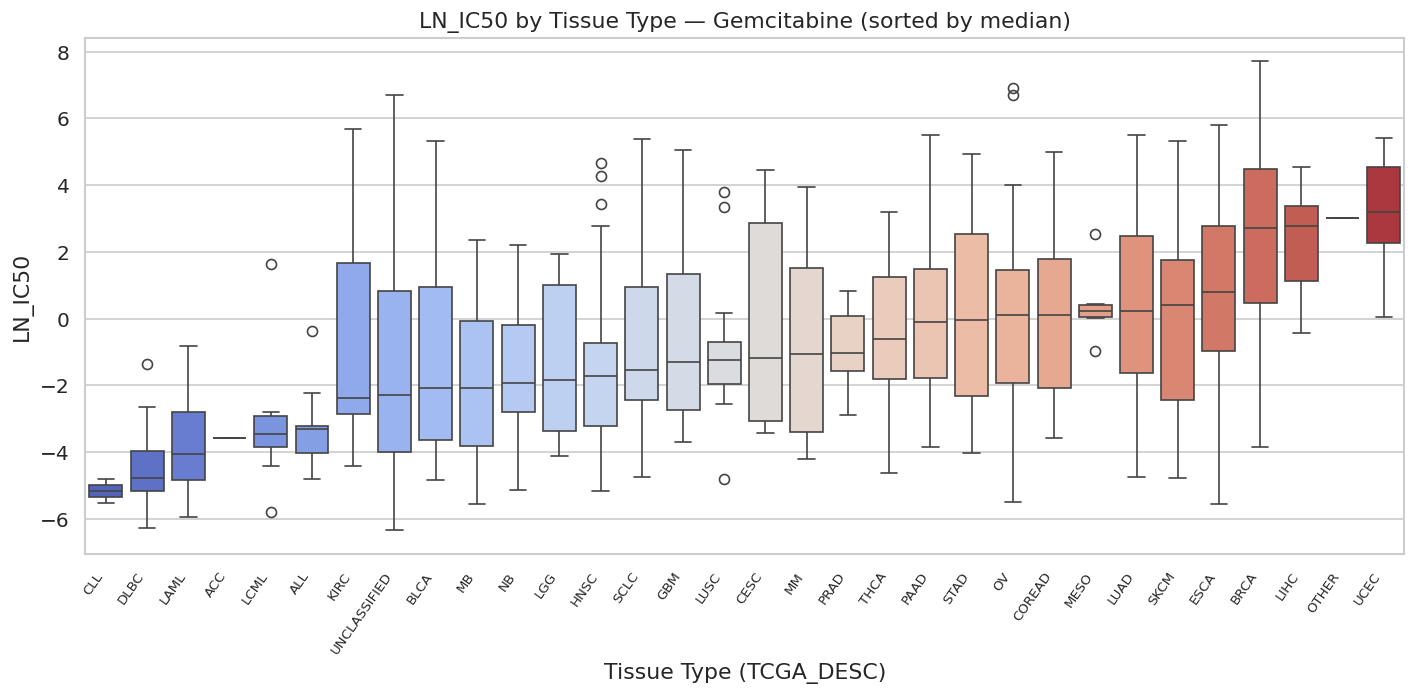

In [20]:
# ── LN_IC50 by tissue type (TCGA_DESC) ──────────────────────────────────────
# Compute median per tissue for ordering
tissue_order = (
    target_df.groupby('TCGA_DESC')['LN_IC50']
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=target_df, x='TCGA_DESC', y='LN_IC50',
            order=tissue_order, palette='coolwarm', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=8)
ax.set_xlabel('Tissue Type (TCGA_DESC)')
ax.set_ylabel('LN_IC50')
ax.set_title(f'LN_IC50 by Tissue Type — {TARGET_DRUG} (sorted by median)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gemcitabine_ln_ic50_by_tissue.png"), dpi=150, bbox_inches="tight")
plt.show()

This plot proves that tissue type alone cannot predict response. If every lung cancer (LUAD) cell responded the same way, the box would be tiny. The fact that they are different means there is a hidden genetic signature within these tissues that your model can find.

While blood-based cancers like CLL (Chronic Lymphocytic Leukemia), DLBC (Large B-cell Lymphoma), and LAML (Acute Myeloid Leukemia) are naturally very sensitive to Gemcitabine. This makes sense biologically, as these cells divide rapidly and are highly susceptible to DNA-disrupting nucleoside analogs.

In [21]:
# ── Tissue sample counts ─────────────────────────────────────────────────────
tissue_counts = target_df['TCGA_DESC'].value_counts()
print(f'Tissue types with data: {len(tissue_counts)}')
print(tissue_counts.head(15).to_string())

Tissue types with data: 32
TCGA_DESC
UNCLASSIFIED    115
LUAD             53
BRCA             43
SCLC             40
COREAD           39
SKCM             36
ESCA             29
OV               28
PAAD             26
DLBC             25
GBM              23
HNSC             22
LAML             20
STAD             19
NB               18


**LUAD** (Lung Adenocarcinoma - 53 samples): This is one of our strongest assets. Since Lung cancer showed massive variance in your boxplot, having 53 samples gives the model enough "examples" to start distinguishing between a sensitive lung cell and a resistant one.

**BRCA** (Breast Cancer - 43 samples): Breast cancer was on the resistant side of our plot. These 43 samples will act as the "Negative Examples" that teach the model what a resistant genetic signature looks like.

**DLBC & LAML** (Blood Cancers - 45 combined samples): These are our "Positive Examples". They are naturally sensitive to Gemcitabine, providing the baseline for high-sensitivity features.

**The "Unclassified"** (115 samples): While these lack a TCGA label, they are still valuable for the Neural Network because the Gene Expression data is still there. The model learns from the genes, not the labels, so these 115 samples significantly increase our statistical power.

---
## Section 8 — Gene Expression Overview

The expression matrix is our feature space. We inspect its shape, value distribution, and confirm duplicates have been handled.

In [22]:
# Final expression matrix (default entries only, already filtered in Section 2c)
expr_final = expr[['ModelID'] + gene_cols].copy()

print(f'Expression matrix (canonical entries):')
print(f'  Rows (cell lines): {len(expr_final):,}')
print(f'  Gene features:     {len(gene_cols):,}')
print(f'  Any nulls:         {expr_final[gene_cols].isnull().any().any()}')
print(f'  Value range:       [{expr_final[gene_cols].values.min():.3f}, {expr_final[gene_cols].values.max():.3f}]')

Expression matrix (canonical entries):
  Rows (cell lines): 1,699
  Gene features:     19,215
  Any nulls:         False
  Value range:       [0.000, 17.361]


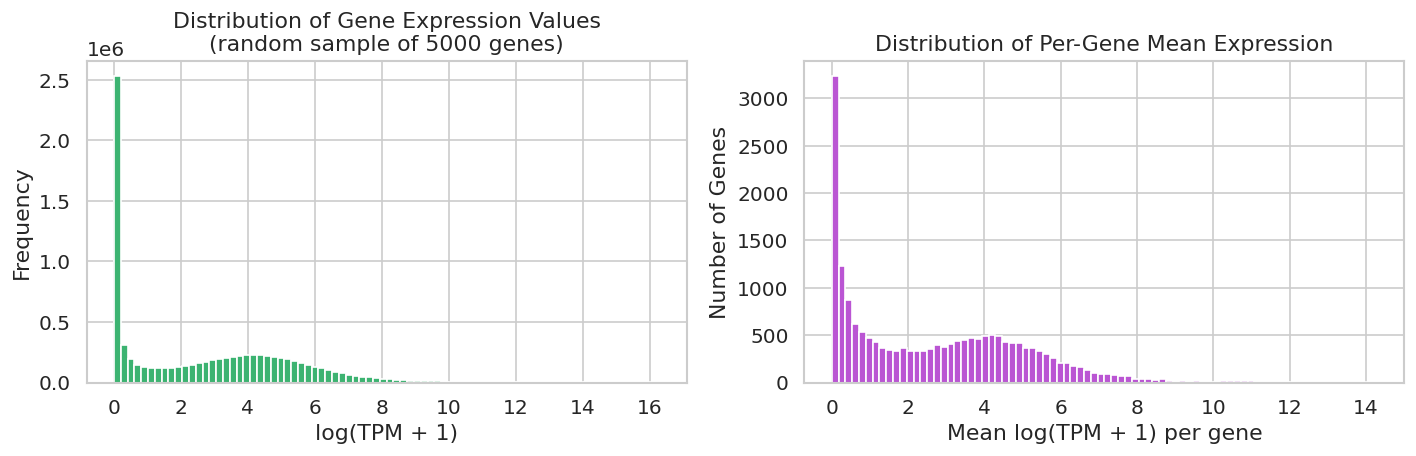

In [23]:
# ── Distribution of expression values (random sample of genes) ───────────────
rng = np.random.default_rng(42)
sample_genes = rng.choice(gene_cols, size=min(5000, len(gene_cols)), replace=False)
sample_values = expr_final[sample_genes].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sample_values, bins=80, color='mediumseagreen', edgecolor='white')
axes[0].set_xlabel('log(TPM + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Gene Expression Values\n(random sample of 5000 genes)')

# Per-gene mean expression (shows housekeeping vs. lowly-expressed genes)
gene_means = expr_final[gene_cols].mean(axis=0)
axes[1].hist(gene_means, bins=80, color='mediumorchid', edgecolor='white')
axes[1].set_xlabel('Mean log(TPM + 1) per gene')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Distribution of Per-Gene Mean Expression')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gene_expression_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Section 9 — Summary & Next Steps

### Key Findings

| Item | Result |
|---|---|
| GDSC2 records (raw) | 242,036 across 286 drugs × 969 cell lines |
| Model.csv entries with COSMIC_ID | 977 / 2,132 |
| After GDSC2 × Model inner join | **946** unique cell lines |
| After adding expression overlap | **698** unique cell lines |
| Duplicate curve fits removed | ~6,288 (multiple NLME fits per cell line × drug) |
| Gene features (after metadata cols) | **19,215** |
| High-coverage drugs (≥690 lines) | **79** |
| **Selected Target Drug** | **Gemcitabine** |
| Gemcitabine coverage | 694 cell lines |
| Gemcitabine LN_IC50 variance | 9.21 (highest among high-coverage drugs) |
| Gemcitabine LN_IC50 range | [−6.34, +7.72] |

### Design Decisions
- **ID bridge**: `Model.csv` is essential — it links GDSC2's `COSMIC_ID` to DepMap's `ModelID`. Without it, no merge is possible.
- **Expression deduplication**: Filter to `IsDefaultEntryForModel == 'Yes'` (string, not boolean) before merging to ensure one row per cell line.
- **GDSC2 deduplication**: Average LN_IC50 across multiple NLME curve fits per (cell line, drug) pair to avoid inflated coverage counts and skewed statistics.
- **Target drug choice**: Gemcitabine — highest LN_IC50 variance (9.21) among drugs with ≥690 cell lines. Sensitivity is mechanistically tied to DCK and SLC29A1 expression, providing a built-in interpretability check for the model.

### Next Steps
1. **Feature Selection / Preprocessing** (`src/preprocess_data.py`)
   - Remove near-zero-variance genes (to be quantified in preprocessing)
   - Apply variance threshold or mutual information filter against Gemcitabine LN_IC50
   - Standardise features (zero mean, unit variance)
2. **Dataset Construction**
   - Build `X` (694 cell lines × ~19,215 genes, after filtering) and `y` (LN_IC50 for Gemcitabine)
   - Train / validation / test split stratified by tissue type (TCGA_DESC)
3. **Model Development**
   - Baseline: Ridge regression (benchmark)
   - DL model: MLP with dropout, batch norm, learning rate scheduler
   - Evaluate: RMSE, Pearson r, R² on held-out test set
   - Interpretability: check if top SHAP features include DCK / SLC29A1